# Bank Customer Churn Analysis

## Objective
The goal of this project is to analyze customer data and identify the key factors driving customer churn, in order to provide actionable business recommendations.

## Dataset
- Source: Kaggle Churn Dataset
- Rows: 10,000 customers
- Target Variable: Exited (1 = churn, 0 = stayed)

## 1. Data Loading & Understanding

In [65]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [66]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  str    
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  str    
 5   Gender           10000 non-null  str    
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), str(3)
memory usage: 1.1 MB


In [67]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


## 2. Data Cleaning

In [38]:
df.isnull().sum()

RowNumber           0
CustomerId          0
Surname             0
CreditScore         0
Geography           0
Gender              0
Age                 0
Tenure              0
Balance             0
NumOfProducts       0
HasCrCard           0
IsActiveMember      0
EstimatedSalary     0
Exited              0
AgeGroup           22
dtype: int64

In [68]:
df.duplicated(subset='CustomerId').sum()

np.int64(0)

No nulls or duplicate rows were found in the dataset, indicating that each record represents a unique customer entry.

## 3. Churn Overview

### What is the overall churn rate?

In [70]:
df['Exited'].value_counts(normalize=True)*100

Exited
0    79.63
1    20.37
Name: proportion, dtype: float64

Approximately 20% of customers have churned, indicating a moderate retention issue.

### Does geography affect churn?

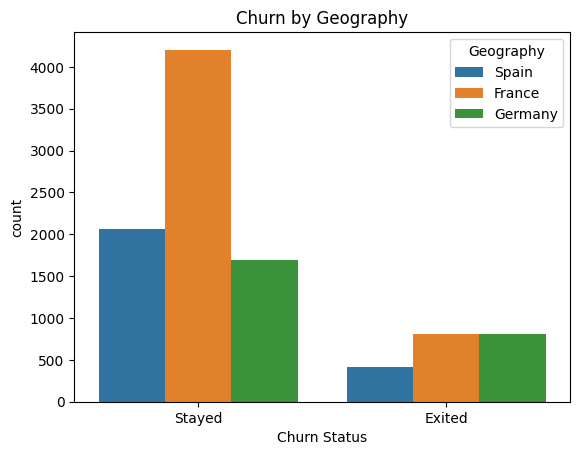

In [78]:
sns.countplot(x='Exited', hue='Geography', data=df)
plt.title('Churn by Geography')
plt.xticks([0,1], ['Stayed', 'Exited'])
plt.xlabel('Churn Status')
plt.show()

Germany has a noticeably higher proportion of churned customers compared to France and Spain, indicating a potential regional issue or stronger competition there.

### Does age affect churn?

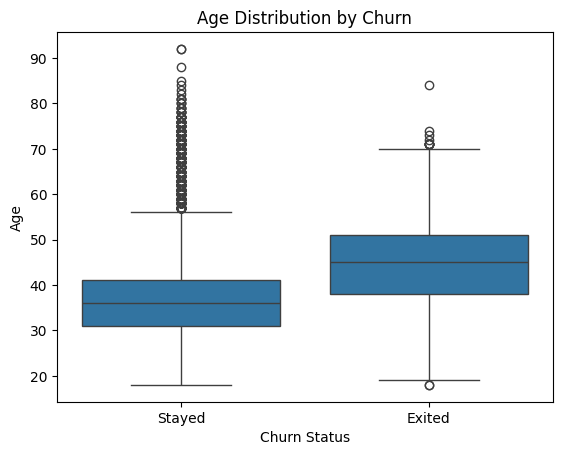

In [79]:
sns.boxplot(x='Exited', y='Age', data=df)
plt.title('Age Distribution by Churn')
plt.xticks([0,1], ['Stayed', 'Exited'])
plt.xlabel('Churn Status')
plt.show()

Average ages of customers who churned range between 40 and 50 years of age.

### Does balance affect churn?

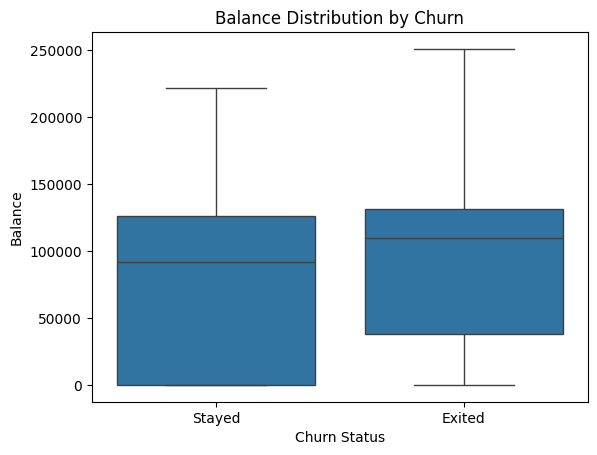

In [80]:
sns.boxplot(x='Exited', y='Balance', data=df)
plt.title('Balance Distribution by Churn')
plt.xticks([0,1], ['Stayed', 'Exited'])
plt.xlabel('Churn Status')
plt.show()

Average balances of customers who churned are slightly higher than those who stayed.

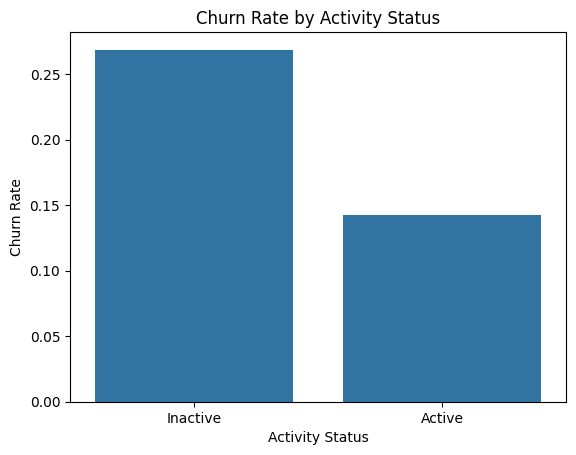

In [81]:
sns.barplot(x='IsActiveMember', y='Exited', data=df, errorbar=None)

plt.title('Churn Rate by Activity Status')
plt.xlabel('Activity Status')
plt.ylabel('Churn Rate')

plt.xticks([0,1], ['Inactive', 'Active'])

plt.show()

Inactive customers have a significantly higher churn rate compared to active customers, indicating that customer engagement is a key driver of retention.

### Correlation Heatmap of Features with Customer Churn

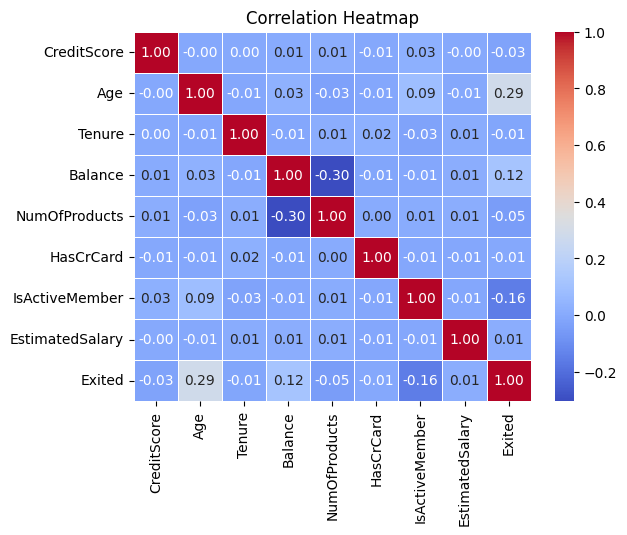

In [76]:
df_corr = df.drop(columns=['CustomerId', 'RowNumber', 'Surname'])
sns.heatmap(df_corr.corr(numeric_only=True), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

The heatmap shows that most variables have weak correlations with churn, indicating that customer churn is influenced by multiple factors rather than a single dominant variable.

Age has the strongest positive correlation with churn, suggesting older customers are more likely to leave. Additionally, active membership shows a negative correlation with churn, indicating that engaged customers are less likely to churn.

### Churn by Age Groups

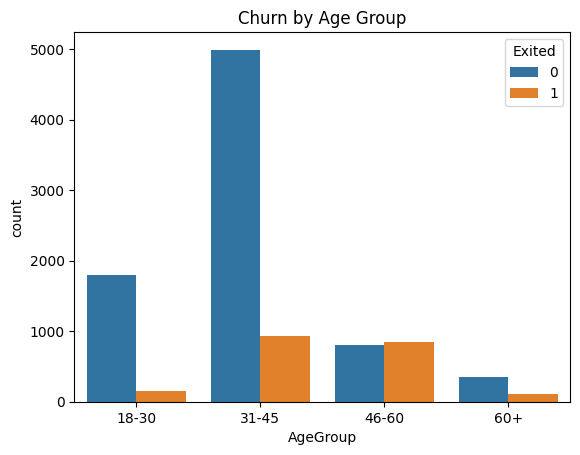

In [64]:
df['AgeGroup'] = pd.cut(df['Age'], bins=[18, 30, 45, 60, 100], labels=['18-30', '31-45', '46-60', '60+'])
sns.countplot(x='AgeGroup', hue='Exited', data=df)
plt.title('Churn by Age Group')
plt.show()

A vey high churn rate (Over 50%) between the age of 46 to 60. 

## Recommendations

Based on the analysis, the following actions are recommended:

1. **Increase Engagement for Inactive Customers**
   - Inactive members show significantly higher churn rates.
   - The bank should implement targeted engagement campaigns such as personalized offers, reminders, and loyalty programs.

2. **Target High-Balance Customers**
   - Customers with higher balances are more likely to churn.
   - Introduce retention strategies such as premium benefits, financial advisory services, or exclusive offers.

3. **Focus on High-Risk Regions**
   - Germany shows the highest churn rate among all regions.
   - Conduct deeper investigation into customer satisfaction and competitive landscape in this region.

4. **Segment Customers by Age**
   - Older customers (especially between 46 to 60) tend to churn more frequently.
   - Tailor services and communication strategies to better meet their needs.